# 분석 단계별 프로세스 - CatBoost 피크 위험 분류

`03_xgboost.ipynb`와 **같은 데이터셋·분할·피크 정의**를 그대로 사용해, `CatBoostClassifier`로 다음 시점(t+1)의 전력 피크 위험 확률 `P(y=1)`을 예측한다.

```text
X_t (전력 이력, 생산량, 기상, 전기요금, 시간/요일 …)  →  CatBoostClassifier  →  P(y_(t+1) = 1)
```

**재사용하는 것 (03_xgboost.ipynb 산출물)**

| 파일 | 내용 |
|---|---|
| `results/peak_dataset.csv` | 03에서 만든 feature 30개 + `target_power` + `split` |
| `results/peak_experiment_meta.json` | 피크 임계값, 분할 경계, feature 목록, RF/XGBoost 분류 threshold |
| `results/peak_baseline_probabilities.csv` | validation/test 구간 RF·XGBoost 확률 (재학습 없이 비교에 사용) |
| `models/xgboost_classifier.json` | XGBoost 모델 (예측 불일치 사례의 기여도 분석에만 사용) |

**데이터 누수 방지**: 피크 임계값은 train으로만 계산하고, encoding·class balancing·hyperparameter·early stopping·분류 threshold는 모두 **validation으로만** 선택한다. Test는 최종 평가에 1회만 사용한다.

## 1. 라이브러리 / 설정

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import catboost
from catboost import CatBoostClassifier, Pool
from xgboost import DMatrix, XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    ConfusionMatrixDisplay,
)

try:
    import shap
    SHAP_AVAILABLE = True
except ImportError:
    SHAP_AVAILABLE = False

print("catboost", catboost.__version__, "| pandas", pd.__version__, "| SHAP plot", SHAP_AVAILABLE)

plt.rc("font", family="AppleGothic")
sns.set(font="AppleGothic", rc={"axes.unicode_minus": False}, style="darkgrid")

catboost 1.2.10 | pandas 3.0.6 | SHAP plot True


/Users/huyn/Project/kamp-resource-optimization-benchmark/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


실험 설정. `PEAK_QUANTILE`은 03과 같아야 한다. 값을 바꾸려면 03을 먼저 같은 값으로 다시 실행해야 baseline 확률이 같은 라벨 기준으로 만들어진다.

In [2]:
SEED = 42
PEAK_QUANTILE = 0.90

RESULTS_DIR = Path("../results")
MODELS_DIR = Path("../models")
MODELS_DIR.mkdir(exist_ok=True)

EARLY_STOPPING_ROUNDS = 100
MAX_ITERATIONS = 2000
# 양성 클래스 PR-AUC로 early stopping.
# class balancing을 켠 경우에도 가중치 없는 PR-AUC로 비교하도록 use_weights=false 를 붙인다
# (CatBoost는 가중치가 없는 학습에서 use_weights 옵션 자체를 허용하지 않는다)
EVAL_METRIC = "PRAUC"

CLASS_THRESHOLD_GRID = np.round(np.arange(0.05, 0.951, 0.05), 2)

## 2. 03_xgboost 산출물 불러오기

In [3]:
meta = json.loads((RESULTS_DIR / "peak_experiment_meta.json").read_text())
dataset = pd.read_csv(RESULTS_DIR / "peak_dataset.csv", index_col="Date", parse_dates=True)
baseline_proba = pd.read_csv(RESULTS_DIR / "peak_baseline_probabilities.csv", index_col="Date", parse_dates=True)

FEATURES = meta["features"]
assert PEAK_QUANTILE == meta["peak_quantile"], "03_xgboost.ipynb 를 같은 PEAK_QUANTILE로 먼저 실행해야 한다"
assert list(dataset.columns) == FEATURES + ["target_power", "split"]

print(f"dataset {dataset.shape}, feature {len(FEATURES)}개")
print("split 크기:", dataset["split"].value_counts().reindex(["train", "validation", "test"]).to_dict())
dataset.head()

dataset (6000, 32), feature 30개
split 크기: {'train': 4920, 'validation': 744, 'test': 336}


,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,lag_48,lag_168,q15_lag1,q30_lag1,...,elec_price,workers,labor_cost,hour,day_of_week,month,Weekend,Vacation,target_power,split
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-08 00:00:00,110.0,100.0,113.0,158.0,129.0,25.0,26.0,62.0,110.0,106.0,...,109.8,0.030534,1.5,0,4,1,0,0,64,train
2021-01-08 01:00:00,64.0,110.0,100.0,147.0,182.0,26.0,22.0,116.0,64.0,63.0,...,109.8,0.000000,1.5,1,4,1,0,0,110,train
2021-01-08 02:00:00,110.0,64.0,110.0,114.0,180.0,22.0,22.0,107.0,87.0,94.0,...,109.8,0.000000,1.5,2,4,1,0,0,111,train
2021-01-08 03:00:00,111.0,110.0,64.0,113.0,175.0,23.0,24.0,110.0,104.0,98.0,...,109.8,0.004866,1.5,3,4,1,0,0,105,train
2021-01-08 04:00:00,105.0,111.0,110.0,100.0,173.0,26.0,26.0,108.0,90.0,105.0,...,109.8,0.371859,1.5,4,4,1,0,0,110,train


## 3. 시계열 분할 / Target 정의

분할은 03과 동일하다.

| 구간 | 기간 |
|---|---|
| Train | 2021-01-08 ~ 2021-07-31 |
| Validation | 2021-08-01 ~ 2021-08-31 |
| Test | 2021-09-01 ~ 2021-09-14 (가이드북 RNN과 동일) |

피크 임계값은 **train의 `target_power`만으로** 다시 계산하고, 03에 저장된 값과 일치하는지 확인한다.

In [4]:
train_df = dataset.loc[dataset["split"] == "train"]
val_df = dataset.loc[dataset["split"] == "validation"]
test_df = dataset.loc[dataset["split"] == "test"]

assert train_df.index.max() < val_df.index.min() <= val_df.index.max() < test_df.index.min()
assert val_df.index.min() == pd.Timestamp(meta["val_start"]) and test_df.index.min() == pd.Timestamp(meta["test_start"])

peak_threshold = float(train_df["target_power"].quantile(PEAK_QUANTILE))
assert peak_threshold == meta["peak_threshold"], "03과 피크 임계값이 다름"
print(f"peak threshold = {peak_threshold:.1f} (train {PEAK_QUANTILE:.0%} quantile)")

y_train = (train_df["target_power"] >= peak_threshold).astype(int)
y_val = (val_df["target_power"] >= peak_threshold).astype(int)
y_test = (test_df["target_power"] >= peak_threshold).astype(int)

label_summary = pd.DataFrame(
    {
        "samples": [len(y_train), len(y_val), len(y_test)],
        "positive": [y_train.sum(), y_val.sum(), y_test.sum()],
        "negative": [(y_train == 0).sum(), (y_val == 0).sum(), (y_test == 0).sum()],
    },
    index=["Train", "Validation", "Test"],
).assign(positive_ratio=lambda t: (t["positive"] / t["samples"]).round(4))
label_summary

peak threshold = 179.0 (train 90% quantile)


,samples,positive,negative,positive_ratio
Train,4920,505,4415,0.1026
Validation,744,101,643,0.1358
Test,336,47,289,0.1399


### 3-1. 데이터 누수 점검

03에서 이미 확인한 항목을 불러온 데이터로 다시 확인한다.
- `lag_1`이 직전 시점의 `target_power`와 같은지 (= 행 T의 feature가 T-1 이하 정보인지)
- target과 같은 feature가 없는지

In [5]:
prev_power = dataset["target_power"].shift(1)
contiguous = dataset.index.to_series().diff() == pd.Timedelta(hours=1)
assert (dataset.loc[contiguous, "lag_1"] == prev_power[contiguous]).all(), "lag_1 ≠ power(t)"

identical = [c for c in FEATURES if np.array_equal(dataset[c].to_numpy(), dataset["target_power"].to_numpy())]
assert not identical, identical
print("누수 점검 통과")

누수 점검 통과


## 4. Feature 구성 — 수치형 / 범주형

**범주형으로 지정한 변수와 이유**

| 변수 | 이유 |
|---|---|
| `hour` | 0~23시는 교대·가동 스케줄을 나타내는 라벨이다. 23시와 0시는 인접하지만 숫자로는 가장 멀다 |
| `day_of_week` | 요일(월~일)은 순서보다 "어느 요일인가"가 가동 여부를 결정한다 |
| `month` | 계절 구간 라벨 |
| `Weekend`, `Vacation` | 0/1 여부 플래그 |

**수치형으로 둔 변수**: 생산량(`production`), 기온, 풍속, 습도, 강수량, 전기요금(`elec_price`), 공장인원(`workers`), 인건비(`labor_cost`), 전력 lag·rolling.
공장인원·인건비는 값 종류가 적어 보여도 **크기 자체에 의미가 있는 연속량**이다. 그래서 범주형으로 바꾸지 않는다.

**주의 — `month`**: train은 1~7월, validation은 8월, test는 9월이다. 범주형 `month`에서 8·9는 train에 없는 범주다. CatBoost는 처음 보는 범주를 prior 값으로 처리한다. 수치형 `month`도 train 범위 밖이라 7월과 같은 쪽으로 분기된다. 어느 방식이든 month 정보는 validation/test에서 제한적으로만 작동한다.

**두 버전을 비교한다 (한 모델에 섞지 않음)**

- **A. Categorical**: `hour`, `day_of_week`, `month`, `Weekend`, `Vacation`을 문자열로 바꿔 `cat_features`로 전달한다.
- **B. Numeric + cyclic**: 달력 변수를 `hour_sin/cos`, `dow_sin/cos`, `month_sin/cos`로 바꾸고, `Weekend`와 `Vacation`은 0/1 수치로 둔다.

In [6]:
CAT_FEATURES = ["hour", "day_of_week", "month", "Weekend", "Vacation"]
NUMERIC_FEATURES = [f for f in FEATURES if f not in CAT_FEATURES]
CYCLIC_PERIODS = {"hour": ("hour", 24), "day_of_week": ("dow", 7), "month": ("month", 12)}


def build_categorical(part: pd.DataFrame) -> pd.DataFrame:
    # CatBoost native categorical: 정수 범주를 문자열로 전달
    return part[FEATURES].astype({c: "string" for c in CAT_FEATURES})


def build_cyclic(part: pd.DataFrame) -> pd.DataFrame:
    cyclic = {}
    for col, (prefix, period) in CYCLIC_PERIODS.items():
        angle = 2 * np.pi * part[col] / period
        cyclic[f"{prefix}_sin"] = np.sin(angle)
        cyclic[f"{prefix}_cos"] = np.cos(angle)
    return pd.concat([part[NUMERIC_FEATURES + ["Weekend", "Vacation"]], pd.DataFrame(cyclic, index=part.index)], axis=1)


ENCODINGS = {
    "A_categorical": {"build": build_categorical, "cat_features": CAT_FEATURES},
    "B_numeric_cyclic": {"build": build_cyclic, "cat_features": []},
}

for name, enc in ENCODINGS.items():
    sample = enc["build"](train_df)
    print(f"{name:<17} feature {sample.shape[1]}개 | cat_features={enc['cat_features']}")
build_cyclic(train_df)[["hour_sin", "hour_cos", "dow_sin", "dow_cos", "month_sin", "month_cos"]].head(3)

A_categorical     feature 30개 | cat_features=['hour', 'day_of_week', 'month', 'Weekend', 'Vacation']
B_numeric_cyclic  feature 33개 | cat_features=[]


,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos
Date,,,,,,
2021-01-08 00:00:00,0.000000,1.000000,-0.433884,-0.900969,0.5,0.866025
2021-01-08 01:00:00,0.258819,0.965926,-0.433884,-0.900969,0.5,0.866025
2021-01-08 02:00:00,0.500000,0.866025,-0.433884,-0.900969,0.5,0.866025


## 5. 평가 함수

03과 같은 정의다. Precision / Recall / F1은 **양성 클래스(피크 = 1)** 기준이고, PR-AUC는 average precision이다.

In [7]:
def evaluate(y_true, proba, threshold: float = 0.5) -> dict:
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {
        "threshold": threshold,
        "Accuracy": accuracy_score(y_true, pred),
        "Precision": precision_score(y_true, pred, pos_label=1, zero_division=0),
        "Recall": recall_score(y_true, pred, pos_label=1, zero_division=0),
        "F1": f1_score(y_true, pred, pos_label=1, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, proba),
        "PR-AUC": average_precision_score(y_true, proba),
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
    }


def threshold_sweep(y_true, proba, grid=CLASS_THRESHOLD_GRID) -> pd.DataFrame:
    return pd.DataFrame([evaluate(y_true, proba, t) for t in grid]).set_index("threshold")


def fit_catboost(encoding: str, **params) -> CatBoostClassifier:
    enc = ENCODINGS[encoding]
    model = CatBoostClassifier(
        loss_function="Logloss",
        eval_metric=EVAL_METRIC if params.get("auto_class_weights") is None else f"{EVAL_METRIC}:use_weights=false",
        iterations=MAX_ITERATIONS,
        random_seed=SEED,
        allow_writing_files=False,
        verbose=False,
        **params,
    )
    model.fit(
        Pool(enc["build"](train_df), y_train, cat_features=enc["cat_features"]),
        eval_set=Pool(enc["build"](val_df), y_val, cat_features=enc["cat_features"]),
        early_stopping_rounds=EARLY_STOPPING_ROUNDS,
        use_best_model=True,
    )
    return model


def val_summary(model: CatBoostClassifier, encoding: str) -> dict:
    proba = model.predict_proba(ENCODINGS[encoding]["build"](val_df))[:, 1]
    sweep = threshold_sweep(y_val, proba)
    return {
        "best_iteration": model.get_best_iteration(),
        "val_PR-AUC": average_precision_score(y_val, proba),
        "val_ROC-AUC": roc_auc_score(y_val, proba),
        "val_F1@0.5": evaluate(y_val, proba)["F1"],
        "val_best_F1": sweep["F1"].max(),
        "val_best_threshold": float(sweep["F1"].idxmax()),
    }

## 6. 실험 1 — Encoding(A/B) × Class balancing

클래스 불균형(train 양성 약 10%)에 대해 두 조건을 비교한다.
- 기본 모델 (`auto_class_weights=None`)
- `auto_class_weights="Balanced"` (양성 가중치 ≈ 음성/양성 비율)

hyperparameter는 CatBoost 기본에 가까운 값(`depth=6`, `learning_rate=0.05`, `l2_leaf_reg=3`)으로 고정한다. iteration 수는 early stopping으로 정한다.

**선택 기준**: validation PR-AUC. 차이가 0.005 이내면 validation best F1이 높은 쪽을 고른다.

In [8]:
BASE_PARAMS = {"depth": 6, "learning_rate": 0.05, "l2_leaf_reg": 3}

stage1 = []
for encoding in ENCODINGS:
    for balancing in [None, "Balanced"]:
        model = fit_catboost(encoding, auto_class_weights=balancing, **BASE_PARAMS)
        stage1.append({"encoding": encoding, "auto_class_weights": balancing or "None", **val_summary(model, encoding)})

stage1 = pd.DataFrame(stage1)


def pick_best(frame: pd.DataFrame, tol: float = 0.005) -> pd.Series:
    top = frame["val_PR-AUC"].max()
    return frame.loc[frame["val_PR-AUC"] >= top - tol].sort_values(["val_best_F1", "val_PR-AUC"], ascending=False).iloc[0]


best_stage1 = pick_best(stage1)
BEST_ENCODING = best_stage1["encoding"]
BEST_BALANCING = None if best_stage1["auto_class_weights"] == "None" else best_stage1["auto_class_weights"]
print(f"선택: encoding={BEST_ENCODING}, auto_class_weights={BEST_BALANCING}")
stage1.round(4)

선택: encoding=A_categorical, auto_class_weights=Balanced


,encoding,auto_class_weights,best_iteration,val_PR-AUC,val_ROC-AUC,val_F1@0.5,val_best_F1,val_best_threshold
0,A_categorical,None,71,0.8642,0.9757,0.7725,0.8060,0.45
1,A_categorical,Balanced,202,0.9030,0.9835,0.8142,0.8309,0.75
2,B_numeric_cyclic,None,22,0.8505,0.9719,0.6375,0.7579,0.40
3,B_numeric_cyclic,Balanced,248,0.8808,0.9807,0.7946,0.8152,0.70


## 7. 실험 2 — 소규모 hyperparameter 탐색 (validation only)

실험 1에서 선택한 encoding과 balancing 위에서 `depth` × `learning_rate` × `l2_leaf_reg`를 12개 조합만 탐색한다.
모든 조합에 early stopping을 적용한다. 선택 기준은 실험 1과 같다.

In [9]:
param_grid = [
    {"depth": d, "learning_rate": lr, "l2_leaf_reg": l2}
    for d in [4, 6, 8]
    for lr in [0.03, 0.1]
    for l2 in [3, 10]
]

stage2 = []
for params in param_grid:
    model = fit_catboost(BEST_ENCODING, auto_class_weights=BEST_BALANCING, **params)
    stage2.append({**params, **val_summary(model, BEST_ENCODING)})

stage2 = pd.DataFrame(stage2)
best_stage2 = pick_best(stage2)
best_cb_params = {
    "depth": int(best_stage2["depth"]),
    "learning_rate": float(best_stage2["learning_rate"]),
    "l2_leaf_reg": float(best_stage2["l2_leaf_reg"]),
    "auto_class_weights": BEST_BALANCING,
}
print("best CatBoost params:", best_cb_params, "| best iteration:", int(best_stage2["best_iteration"]))
stage2.sort_values("val_PR-AUC", ascending=False).round(4)

best CatBoost params: {'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 3.0, 'auto_class_weights': 'Balanced'} | best iteration: 383


,depth,learning_rate,l2_leaf_reg,best_iteration,val_PR-AUC,val_ROC-AUC,val_F1@0.5,val_best_F1,val_best_threshold
4,6,0.03,3,383,0.9060,0.9837,0.8087,0.8390,0.80
1,4,0.03,10,459,0.8975,0.9836,0.7778,0.8468,0.70
0,4,0.03,3,403,0.8968,0.9833,0.7967,0.8304,0.70
3,4,0.10,10,202,0.8946,0.9831,0.8000,0.8476,0.75
6,6,0.10,3,125,0.8923,0.9818,0.8070,0.8251,0.60
8,8,0.03,3,308,0.8861,0.9810,0.8085,0.8410,0.85
9,8,0.03,10,475,0.8860,0.9811,0.8000,0.8246,0.75
5,6,0.03,10,269,0.8852,0.9815,0.7481,0.8286,0.80
2,4,0.10,3,155,0.8828,0.9810,0.8066,0.8117,0.60
7,6,0.10,10,143,0.8792,0.9815,0.7854,0.8246,0.75


## 8. 최종 CatBoost 모델 학습

In [10]:
cb_model = fit_catboost(BEST_ENCODING, **best_cb_params)
CB_CAT_FEATURES = ENCODINGS[BEST_ENCODING]["cat_features"]

X_val_cb = ENCODINGS[BEST_ENCODING]["build"](val_df)
X_test_cb = ENCODINGS[BEST_ENCODING]["build"](test_df)
cb_val_proba = cb_model.predict_proba(X_val_cb)[:, 1]
cb_test_proba = cb_model.predict_proba(X_test_cb)[:, 1]

print(f"encoding={BEST_ENCODING}, iterations used={cb_model.tree_count_}, cat_features={CB_CAT_FEATURES}")

encoding=A_categorical, iterations used=384, cat_features=['hour', 'day_of_week', 'month', 'Weekend', 'Vacation']


## 9. Probability threshold tuning (validation)

0.05~0.95 구간에서 validation F1이 최대인 threshold를 고르고, **Test에 그대로 적용**한다.

CatBoost best threshold (validation F1) = 0.8


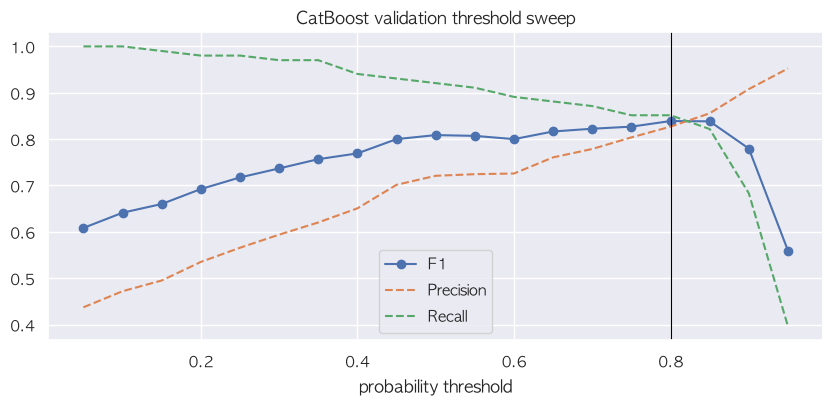

,Precision,Recall,F1,TP,FP,FN
threshold,,,,,,
0.05,0.4372,1.0000,0.6084,101,130,0
0.10,0.4720,1.0000,0.6413,101,113,0
0.15,0.4950,0.9901,0.6601,100,102,1
0.20,0.5351,0.9802,0.6923,99,86,2
0.25,0.5657,0.9802,0.7174,99,76,2
0.30,0.5939,0.9703,0.7368,98,67,3
0.35,0.6203,0.9703,0.7568,98,60,3
0.40,0.6507,0.9406,0.7692,95,51,6
0.45,0.7015,0.9307,0.8000,94,40,7


In [11]:
cb_sweep = threshold_sweep(y_val, cb_val_proba)
cb_threshold = float(cb_sweep["F1"].idxmax())
print(f"CatBoost best threshold (validation F1) = {cb_threshold}")

fig, ax = plt.subplots(figsize=(10, 4))
for metric, style in [("F1", "-o"), ("Precision", "--"), ("Recall", "--")]:
    ax.plot(cb_sweep.index, cb_sweep[metric], style, label=metric)
ax.axvline(cb_threshold, color="black", linewidth=0.8)
ax.set_xlabel("probability threshold")
ax.set_title("CatBoost validation threshold sweep")
ax.legend()
plt.show()

cb_sweep[["Precision", "Recall", "F1", "TP", "FP", "FN"]].round(4)

## 10. Test 평가 — RF / XGBoost / CatBoost

RF와 XGBoost는 03에서 저장한 확률과 threshold를 그대로 쓴다(재학습 없음). 세 모델 모두 **validation에서 고른 threshold**로 평가한다.

In [12]:
test_baseline = baseline_proba.loc[baseline_proba["split"] == "test"]
assert test_baseline.index.equals(test_df.index)

MODEL_PROBA = {
    "Random Forest": (test_baseline["rf_probability"].to_numpy(), meta["rf_threshold"]),
    "XGBoost": (test_baseline["xgb_probability"].to_numpy(), meta["xgb_threshold"]),
    "CatBoost": (cb_test_proba, cb_threshold),
}
test_eval = {name: evaluate(y_test, proba, thr) for name, (proba, thr) in MODEL_PROBA.items()}

METRIC_COLS = ["Precision", "Recall", "F1", "ROC-AUC", "PR-AUC"]
comparison = pd.DataFrame(test_eval).T[["threshold"] + METRIC_COLS]
comparison.index.name = "Model"
comparison.astype(float).round(4)

,threshold,Precision,Recall,F1,ROC-AUC,PR-AUC
Model,,,,,,
Random Forest,0.50,0.6190,0.8298,0.7091,0.9553,0.7371
XGBoost,0.65,0.6066,0.7872,0.6852,0.9533,0.7113
CatBoost,0.80,0.6481,0.7447,0.6931,0.9590,0.7575


### 10-1. 양성 클래스(피크) 기준 Precision / Recall / F1

In [13]:
positive_class = pd.DataFrame(test_eval).T[["TP", "FP", "FN", "Precision", "Recall", "F1"]].astype(float)
positive_class = positive_class.assign(
    actual_peaks=int(y_test.sum()),
    predicted_peaks=lambda t: t["TP"] + t["FP"],
)
positive_class.columns.name = "peak class (y=1)"
positive_class[["actual_peaks", "predicted_peaks", "TP", "FP", "FN", "Precision", "Recall", "F1"]].round(4)

peak class (y=1),actual_peaks,predicted_peaks,TP,FP,FN,Precision,Recall,F1
Random Forest,47,63.0,39.0,24.0,8.0,0.6190,0.8298,0.7091
XGBoost,47,61.0,37.0,24.0,10.0,0.6066,0.7872,0.6852
CatBoost,47,54.0,35.0,19.0,12.0,0.6481,0.7447,0.6931


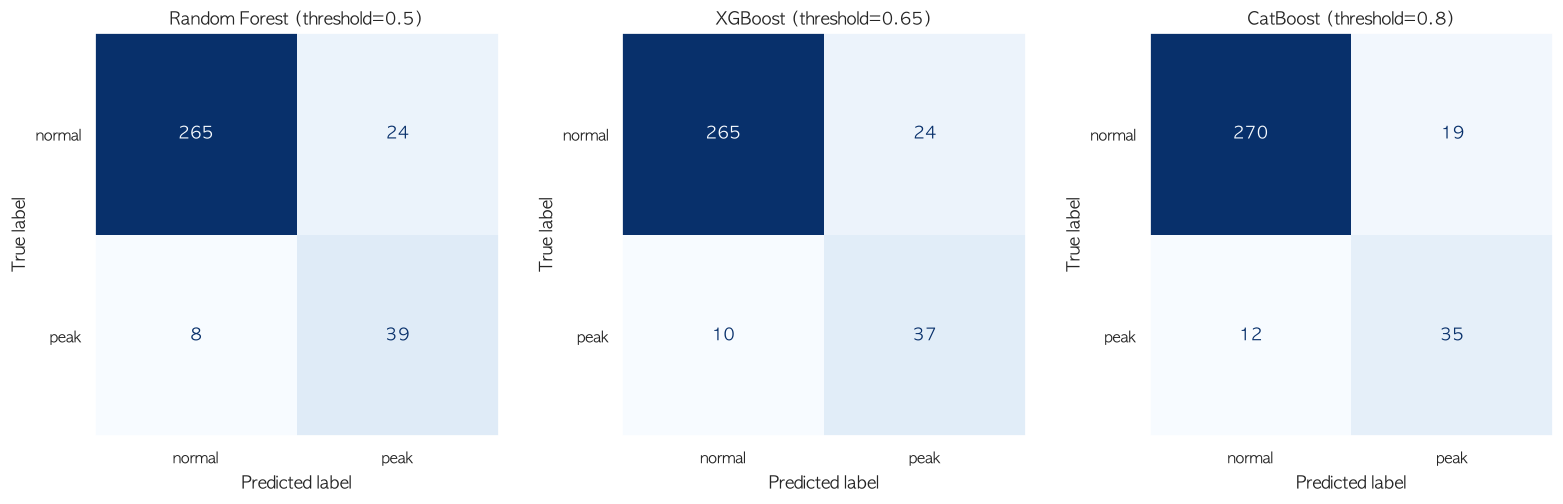

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, (proba, thr)) in zip(axes, MODEL_PROBA.items()):
    ConfusionMatrixDisplay(
        confusion_matrix(y_test, (proba >= thr).astype(int), labels=[0, 1]),
        display_labels=["normal", "peak"],
    ).plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name} (threshold={thr})")
    ax.grid(False)
plt.tight_layout()
plt.show()

In [15]:
cb_default_eval = evaluate(y_test, cb_test_proba, 0.5)
print(f"참고 — CatBoost @0.5: F1 {cb_default_eval['F1']:.4f}, Precision {cb_default_eval['Precision']:.4f}, "
      f"Recall {cb_default_eval['Recall']:.4f} (threshold는 validation 선택값을 최종으로 사용)")

diff = comparison.loc["CatBoost", METRIC_COLS].astype(float)
for other in ["Random Forest", "XGBoost"]:
    delta = diff - comparison.loc[other, METRIC_COLS].astype(float)
    print(f"CatBoost - {other:<13}: " + ", ".join(f"{m} {v:+.4f}" for m, v in delta.items()))

참고 — CatBoost @0.5: F1 0.7059, Precision 0.5833, Recall 0.8936 (threshold는 validation 선택값을 최종으로 사용)
CatBoost - Random Forest: Precision +0.0291, Recall -0.0851, F1 -0.0160, ROC-AUC +0.0037, PR-AUC +0.0204
CatBoost - XGBoost      : Precision +0.0416, Recall -0.0426, F1 +0.0079, ROC-AUC +0.0057, PR-AUC +0.0461


### 10-2. 결과 해석 (`PEAK_QUANTILE = 0.90`, `SEED = 42` 실행 기준)

**Validation 선택 과정**
- **Class balancing 효과가 크다.** `auto_class_weights="Balanced"`를 켜면 validation PR-AUC가 A 0.864 → 0.903, B 0.851 → 0.881로 올랐다. XGBoost에서 `scale_pos_weight`가 PR-AUC를 거의 바꾸지 않았던 것과 다르다.
- **범주형 encoding(A)이 cyclic encoding(B)보다 높았다.** balancing 여부와 관계없이 validation PR-AUC가 0.014~0.022 높다.

**Test 결과**
- **순위 품질(threshold와 무관한 지표)은 CatBoost가 가장 좋다.** PR-AUC 0.7575로 RF(0.7371)보다 +0.020, XGBoost(0.7113)보다 +0.046 높다. ROC-AUC도 0.9590으로 셋 중 가장 높다.
- **F1은 RF > CatBoost > XGBoost 순이다.** 0.7091 > 0.6931 > 0.6852로 차이가 작다. 양성이 47건뿐이라 TP 1건 차이가 Recall 약 0.02에 해당한다.
- **validation에서 고른 threshold 0.8이 높다.** 그래서 CatBoost는 Precision이 가장 높고(0.648, 오탐 19건으로 최소) Recall이 가장 낮다(0.745, 놓친 피크 12건으로 최다).
  같은 모델을 0.5로 쓰면 Recall 0.894, F1 0.706이다. 다만 이 값은 test를 보고 알게 된 것이라 채택하지 않는다.
- **validation과 test의 격차는 RF·XGBoost와 같은 패턴이다.** validation PR-AUC 0.906 → test 0.758로 떨어진다. 8월 validation에 하계 휴무 주간과 복사된 구간이 섞여 있기 때문이다.

**판단**: CatBoost는 "피크 위험 확률의 순위"를 가장 잘 매긴다. 하지만 운영 threshold에서의 F1은 RF와 비슷한 수준이다. 피크를 놓치는 비용이 오탐 비용보다 크다면, threshold를 낮추거나 Recall 기준으로 threshold를 고르는 것을 검토한다. 이 결정도 validation 기준으로 해야 한다.

## 11. 결과 저장

- `results/catboost_predictions.csv`: `Date, actual_label, predicted_label, risk_probability, actual_power`
- `results/model_comparison.csv`: 03의 비교표에 CatBoost 행을 추가한다. 이미 있는 CatBoost 행은 교체하므로 다시 실행해도 행이 중복되지 않는다.
- `models/catboost_classifier.cbm` + `catboost_classifier_meta.json`

In [16]:
catboost_predictions = pd.DataFrame(
    {
        "Date": test_df.index,
        "actual_label": y_test.to_numpy(),
        "predicted_label": (cb_test_proba >= cb_threshold).astype(int),
        "risk_probability": cb_test_proba,
        "actual_power": test_df["target_power"].to_numpy(),
    }
)
catboost_predictions.to_csv(RESULTS_DIR / "catboost_predictions.csv", index=False)

previous = pd.read_csv(RESULTS_DIR / "model_comparison.csv", index_col="Model")
previous = previous.loc[~previous.index.str.startswith("CatBoost")]
catboost_rows = pd.DataFrame(
    {f"CatBoost @0.5": cb_default_eval, f"CatBoost @{cb_threshold}": test_eval["CatBoost"]}
).T[previous.columns]
model_comparison = pd.concat([previous, catboost_rows])
model_comparison.index.name = "Model"
model_comparison.to_csv(RESULTS_DIR / "model_comparison.csv")

cb_model.save_model(MODELS_DIR / "catboost_classifier.cbm")
(MODELS_DIR / "catboost_classifier_meta.json").write_text(
    json.dumps(
        {
            "peak_quantile": PEAK_QUANTILE,
            "peak_threshold": peak_threshold,
            "classification_threshold": cb_threshold,
            "encoding": BEST_ENCODING,
            "cat_features": CB_CAT_FEATURES,
            "params": best_cb_params,
            "iterations": cb_model.tree_count_,
            "features": list(X_test_cb.columns),
        },
        ensure_ascii=False,
        indent=2,
    )
)
model_comparison.astype(float).round(4)

,threshold,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,TP,FP,FN,TN
Model,,,,,,,,,,,
Persistence (lag_1 ≥ peak),179.00,0.8452,0.4468,0.4468,0.4468,0.8623,0.5295,21.0,26.0,26.0,263.0
Random Forest @0.5,0.50,0.9048,0.6190,0.8298,0.7091,0.9553,0.7371,39.0,24.0,8.0,265.0
XGBoost default (no spw) @0.5,0.50,0.9048,0.6471,0.7021,0.6735,0.9561,0.7417,33.0,18.0,14.0,271.0
XGBoost default (spw) @0.5,0.50,0.8988,0.5915,0.8936,0.7119,0.9567,0.7473,42.0,29.0,5.0,260.0
XGBoost tuned @0.5,0.50,0.9018,0.6000,0.8936,0.7179,0.9533,0.7113,42.0,28.0,5.0,261.0
XGBoost tuned @0.65,0.65,0.8988,0.6066,0.7872,0.6852,0.9533,0.7113,37.0,24.0,10.0,265.0
CatBoost @0.5,0.50,0.8958,0.5833,0.8936,0.7059,0.9590,0.7575,42.0,30.0,5.0,259.0
CatBoost @0.8,0.80,0.9077,0.6481,0.7447,0.6931,0.9590,0.7575,35.0,19.0,12.0,270.0


## 12. Feature Importance / SHAP

- CatBoost native importance (`PredictionValuesChange`)
- CatBoost 내장 SHAP(`type="ShapValues"`)으로 test 구간 log-odds 기여도를 계산한다. 범주형 feature도 그대로 처리된다.

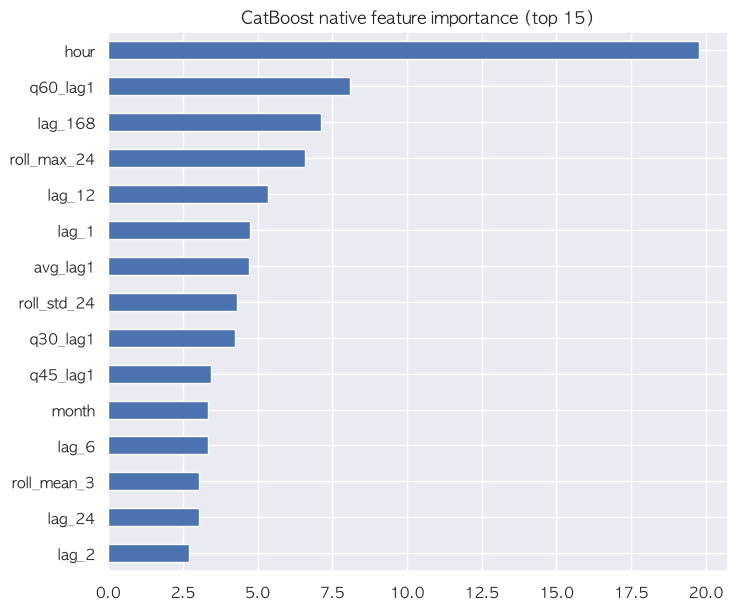

,importance
hour,19.761
q60_lag1,8.103
lag_168,7.118
roll_max_24,6.570
lag_12,5.355
lag_1,4.750
avg_lag1,4.707
roll_std_24,4.308
q30_lag1,4.248
q45_lag1,3.436


In [17]:
native_importance = (
    pd.Series(cb_model.get_feature_importance(), index=X_test_cb.columns, name="importance")
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 7))
native_importance.head(15).iloc[::-1].plot.barh(ax=ax)
ax.set_title("CatBoost native feature importance (top 15)")
plt.show()

native_importance.head(10).round(3).to_frame()

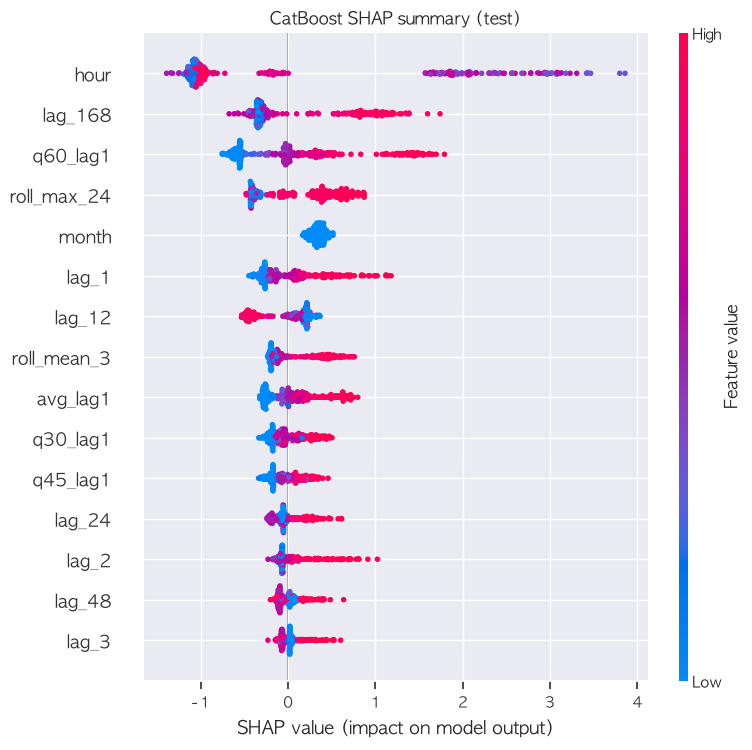

,mean_abs_shap
hour,1.3437
lag_168,0.5213
q60_lag1,0.4728
roll_max_24,0.4353
month,0.3451
lag_1,0.2719
lag_12,0.2586
roll_mean_3,0.2410
avg_lag1,0.2237
q30_lag1,0.1582


In [18]:
test_pool = Pool(X_test_cb, y_test, cat_features=CB_CAT_FEATURES)
cb_shap = cb_model.get_feature_importance(test_pool, type="ShapValues")[:, :-1]  # 마지막 열은 base value
cb_shap = pd.DataFrame(cb_shap, index=X_test_cb.index, columns=X_test_cb.columns)

# 색상 표시용 수치 버전 (범주형 문자열 → 정수)
X_test_view = X_test_cb.apply(pd.to_numeric)

if SHAP_AVAILABLE:
    shap.summary_plot(cb_shap.to_numpy(), X_test_view, max_display=15, show=False)
    plt.title("CatBoost SHAP summary (test)")
    plt.show()

shap_importance = cb_shap.abs().mean().sort_values(ascending=False).rename("mean_abs_shap")
shap_importance.head(10).round(4).to_frame()

### 12-1. 질문별 분석

아래 수치는 test 구간 SHAP 값(log-odds)으로 계산한다.
- **변수 그룹별 비중**: mean |SHAP|의 합을 그룹별로 나눈 값
- **피크 위험 증가 기여**: 모델이 피크로 예측한 시점에서 SHAP이 양(+)인 기여의 평균

In [19]:
def feature_group(name: str) -> str:
    if name in {"lag_1", "q15_lag1", "q30_lag1", "q45_lag1", "q60_lag1", "avg_lag1", "roll_mean_3"}:
        return "직전 전력 (t 시점)"
    if name.startswith(("lag_", "roll_")):
        return "과거 전력 이력 (2h~1주)"
    if name == "production":
        return "생산량"
    if name in {"workers", "labor_cost", "elec_price"}:
        return "인력/요금"
    if name in {"temperature", "wind_speed", "humidity", "precipitation"}:
        return "기상"
    return "시간/요일/휴일"


group_share = (shap_importance.groupby(shap_importance.index.map(feature_group)).sum() / shap_importance.sum()).sort_values(ascending=False)

predicted_peak = cb_test_proba >= cb_threshold
risk_up = cb_shap.loc[predicted_peak].clip(lower=0).mean().sort_values(ascending=False)
rank = {f: i + 1 for i, f in enumerate(shap_importance.index)}

print("[변수 그룹별 SHAP 비중]")
for g, v in group_share.items():
    print(f"  {g:<18} {v:6.1%}")

print("\n[Q1] 피크 위험 증가에 가장 큰 영향 (피크 예측 시점의 +SHAP 평균, top 5)")
for f, v in risk_up.head(5).items():
    print(f"  {f:<14} +{v:.3f}")

prod_corr = np.corrcoef(X_test_view["production"], cb_shap["production"])[0, 1]
print(f"\n[Q2] 생산량: 중요도 {rank['production']}위 / {len(rank)}, SHAP 비중 {shap_importance['production'] / shap_importance.sum():.1%}, "
      f"생산량-SHAP 상관 {prod_corr:+.2f}")

time_feats = [f for f in shap_importance.index if feature_group(f) == "시간/요일/휴일"]
print(f"\n[Q3] 시간/요일 정보: 합계 비중 {group_share['시간/요일/휴일']:.1%} | 개별 순위 " +
      ", ".join(f"{f} {rank[f]}위" for f in time_feats))

print(f"\n[Q4] 직전 전력 lag: lag_1 {rank['lag_1']}위, q60_lag1 {rank['q60_lag1']}위, avg_lag1 {rank['avg_lag1']}위 | "
      f"직전 전력 그룹 비중 {group_share['직전 전력 (t 시점)']:.1%}, 과거 이력 그룹 {group_share['과거 전력 이력 (2h~1주)']:.1%}")

[변수 그룹별 SHAP 비중]
  과거 전력 이력 (2h~1주)    34.2%
  시간/요일/휴일            32.0%
  직전 전력 (t 시점)        28.7%
  기상                   2.4%
  인력/요금                1.7%
  생산량                  0.9%

[Q1] 피크 위험 증가에 가장 큰 영향 (피크 예측 시점의 +SHAP 평균, top 5)
  hour           +2.179
  q60_lag1       +0.944
  lag_168        +0.934
  roll_max_24    +0.586
  lag_1          +0.506

[Q2] 생산량: 중요도 22위 / 30, SHAP 비중 0.9%, 생산량-SHAP 상관 +0.59

[Q3] 시간/요일 정보: 합계 비중 32.0% | 개별 순위 hour 1위, month 5위, day_of_week 18위, Weekend 29위, Vacation 30위

[Q4] 직전 전력 lag: lag_1 6위, q60_lag1 3위, avg_lag1 9위 | 직전 전력 그룹 비중 28.7%, 과거 이력 그룹 34.2%


### 12-2. 질문별 답 (test 구간 SHAP 기준)

**Q1. 피크 위험 증가에 가장 큰 영향을 준 변수는?**

`hour`다. native importance 19.8(2위의 약 2.4배), mean |SHAP| 1.34(2위의 약 2.6배)로 압도적이다.
피크로 예측한 시점에서 위험을 올린 기여도는 `hour` +2.18, `q60_lag1` +0.94, `lag_168` +0.93 순이다. 즉 "가동 시간대인가", "지금 전력이 높은가", "지난주 같은 시각이 높았는가"가 핵심이다.

**Q2. 생산량의 영향은?**

작다. 30개 중 22위이고, SHAP 비중은 0.9%다.
생산량과 SHAP의 상관이 +0.59라서 방향은 "생산량이 많을수록 위험 증가"가 맞다. 하지만 생산 상태는 이미 전력 이력과 가동 시간대에 반영되어 있어 추가 정보가 거의 없다.

**Q3. 시간/요일 정보는 중요한가?**

`hour`는 매우 중요하다. 그룹 비중 32% 중 대부분이 `hour`다.
- `month`가 5위로 나오지만 실질적 정보는 아니다. test는 모두 9월(train에 없는 범주)이라 month의 SHAP이 거의 상수(평균 +0.35, 표준편차 0.06)다. month를 7로 바꿔도 평균 확률이 0.212 → 0.220으로 거의 변하지 않는다. 처음 보는 범주에 대한 offset에 가깝다.
- `day_of_week` 18위, `Weekend` 29위, `Vacation` 30위다. 주말·휴일 여부는 `lag_168`(지난주 같은 요일·시각)과 `lag_24`가 이미 담고 있다.

**Q4. 직전 전력량 lag는 얼마나 중요한가?**

중요하다. t 시점 전력 그룹의 SHAP 비중이 28.7%다.
- 그중 시간당 최대값 `lag_1`(6위)보다 **직전 15분 값 `q60_lag1`(3위)**이 더 유용하다. 시간이 끝날 무렵의 추세가 다음 시간의 피크를 더 잘 나타낸다.
- 2시간~1주 전 이력 그룹은 34.2%이고, 대부분이 `lag_168`(SHAP 2위)이다.

**XGBoost와의 차이**: XGBoost는 `lag_168`이 1위(gain 24%)이고 `hour`는 6위였다. CatBoost는 `hour`를 범주형으로 받아 시간대 자체를 가장 강한 신호로 쓴다. 두 모델이 같은 데이터에서 서로 다른 신호에 의존한다.

## 13. XGBoost vs CatBoost — 판단이 갈린 test 샘플

두 모델(각자의 validation threshold 적용)의 예측이 다른 시점을 뽑는다. 각 시점에서 모델별로 **SHAP 기여도가 큰 feature 3개**를 비교한다.
XGBoost는 03에서 저장한 모델을 불러와 기여도만 계산한다. 불러온 모델의 확률이 저장된 확률과 같은지 먼저 확인한다.

In [20]:
xgb_model = XGBClassifier()
xgb_model.load_model(MODELS_DIR / "xgboost_classifier.json")
X_test_xgb = test_df[FEATURES]
assert np.allclose(xgb_model.predict_proba(X_test_xgb)[:, 1], test_baseline["xgb_probability"], atol=1e-6)

xgb_contrib = xgb_model.get_booster().predict(DMatrix(X_test_xgb), pred_contribs=True)[:, :-1]
xgb_shap = pd.DataFrame(xgb_contrib, index=X_test_xgb.index, columns=FEATURES)

xgb_proba, xgb_thr = MODEL_PROBA["XGBoost"]
cases = test_df[FEATURES].assign(
    actual_power=test_df["target_power"],
    actual_label=y_test,
    xgb_prob=xgb_proba,
    cb_prob=cb_test_proba,
    xgb_pred=(xgb_proba >= xgb_thr).astype(int),
    cb_pred=(cb_test_proba >= cb_threshold).astype(int),
)
disagree = cases.loc[cases["xgb_pred"] != cases["cb_pred"]].copy()
disagree["correct_model"] = np.where(disagree["cb_pred"] == disagree["actual_label"], "CatBoost", "XGBoost")


def top_contrib(shap_row: pd.Series, k: int = 3) -> str:
    top = shap_row.reindex(shap_row.abs().sort_values(ascending=False).index).head(k)
    return ", ".join(f"{f}{v:+.2f}" for f, v in top.items())


disagree["xgb_top3"] = [top_contrib(xgb_shap.loc[i]) for i in disagree.index]
disagree["cb_top3"] = [top_contrib(cb_shap.loc[i]) for i in disagree.index]

print(f"판단이 갈린 test 샘플: {len(disagree)}건 / {len(cases)}")
print(pd.crosstab(disagree["correct_model"], disagree["actual_label"].map({1: "실제 피크", 0: "실제 정상"})))

판단이 갈린 test 샘플: 17건 / 336
actual_label   실제 정상  실제 피크
correct_model              
CatBoost           7      3
XGBoost            2      5


In [21]:
view_cols = ["actual_power", "actual_label", "xgb_prob", "cb_prob", "correct_model", "lag_1", "lag_24", "lag_168", "hour", "day_of_week", "production"]
disagree[view_cols].round(3)

,actual_power,actual_label,xgb_prob,cb_prob,correct_model,lag_1,lag_24,lag_168,hour,day_of_week,production
Date,,,,,,,,,,,
2021-09-01 08:00:00,198,1,0.248,0.801,CatBoost,139.0,177.0,182.0,8,2,1747.0
2021-09-02 08:00:00,171,0,0.634,0.900,XGBoost,160.0,198.0,196.0,8,3,598.0
2021-09-02 09:00:00,198,1,0.871,0.737,XGBoost,171.0,189.0,199.0,9,3,811.0
2021-09-03 11:00:00,190,1,0.887,0.782,XGBoost,169.0,188.0,182.0,11,4,517.0
2021-09-03 15:00:00,162,0,0.582,0.893,XGBoost,181.0,177.0,175.0,15,4,280.0
2021-09-06 08:00:00,180,1,0.565,0.894,CatBoost,81.0,27.0,183.0,8,0,0.0
2021-09-07 08:00:00,192,1,0.829,0.670,XGBoost,160.0,180.0,177.0,8,1,548.0
2021-09-07 16:00:00,167,0,0.946,0.637,CatBoost,174.0,152.0,180.0,16,1,751.0
2021-09-08 10:00:00,160,0,0.661,0.513,CatBoost,163.0,178.0,196.0,10,2,1154.0


In [22]:
pd.set_option("display.max_colwidth", 80)
disagree[["actual_power", "xgb_prob", "cb_prob", "xgb_top3", "cb_top3"]].round(3)

,actual_power,xgb_prob,cb_prob,xgb_top3,cb_top3
Date,,,,,
2021-09-01 08:00:00,198,0.248,0.801,"lag_12-1.53, lag_168+0.77, hour+0.65","hour+3.10, lag_168+1.22, lag_48+0.40"
2021-09-02 08:00:00,171,0.634,0.900,"lag_168+0.85, hour+0.69, lag_12-0.56","hour+2.97, lag_168+1.01, roll_max_24+0.71"
2021-09-02 09:00:00,198,0.871,0.737,"lag_168+0.97, lag_2-0.42, roll_max_24+0.41","hour+1.73, lag_168+1.12, q60_lag1+0.62"
2021-09-03 11:00:00,190,0.887,0.782,"lag_168+1.00, roll_max_24+0.50, lag_12+0.50","hour+1.68, lag_168+1.02, roll_max_24+0.67"
2021-09-03 15:00:00,162,0.582,0.893,"q60_lag1+0.84, lag_168+0.50, avg_lag1+0.50","hour+1.74, q60_lag1+1.40, avg_lag1+0.72"
2021-09-06 08:00:00,180,0.565,0.894,"q60_lag1-1.99, lag_168+1.51, hour+0.81","hour+3.80, lag_168+1.74, lag_12+0.36"
2021-09-07 08:00:00,192,0.829,0.670,"lag_168+0.86, hour+0.69, lag_2-0.39","hour+3.02, lag_168+1.02, q60_lag1+0.35"
2021-09-07 16:00:00,167,0.946,0.637,"lag_2+1.26, lag_168+1.08, hour-0.84","lag_168+1.10, lag_2+1.02, q60_lag1+0.53"
2021-09-08 10:00:00,160,0.661,0.513,"lag_168+0.96, q30_lag1-0.45, avg_lag1-0.43","hour+1.63, lag_168+0.95, roll_max_24+0.50"


In [23]:
# 판단이 갈린 샘플에서 두 모델의 기여도 차이가 가장 큰 feature
common = [f for f in FEATURES if f in cb_shap.columns]
contrib_gap = (cb_shap.loc[disagree.index, common] - xgb_shap.loc[disagree.index, common]).abs().mean().sort_values(ascending=False)
print("불일치 샘플에서 CatBoost-XGBoost SHAP 차이 평균 (top 8, 공통 feature):")
contrib_gap.head(8).round(3).to_frame("mean_abs_gap")

불일치 샘플에서 CatBoost-XGBoost SHAP 차이 평균 (top 8, 공통 feature):


,mean_abs_gap
hour,1.719
q60_lag1,0.432
avg_lag1,0.334
q30_lag1,0.313
lag_2,0.312
lag_12,0.263
roll_mean_3,0.262
temperature,0.245


### 13-1. 판단이 갈린 사례 해석

두 모델의 예측이 다른 시점은 17건이다. CatBoost가 맞힌 것이 10건(오탐 회피 7, 피크 적중 3), XGBoost가 맞힌 것이 7건(오탐 회피 2, 피크 적중 5)이다.
두 모델의 SHAP 차이가 가장 큰 feature는 `hour`(평균 차이 1.72)이고, 다음이 `q60_lag1`(0.43)이다.

**CatBoost만 맞힌 피크 — 08시 가동 시작, 월요일**
- 09-01 08시: XGBoost는 `lag_12`(-1.53) 때문에 확률을 0.25로 낮췄다. CatBoost는 `hour` +3.10으로 0.80을 냈다.
- 09-06 08시(월): 주말 직후라 `lag_24`가 27이고, 직전 전력도 81로 낮았다. XGBoost는 `q60_lag1` -1.99로 확률이 깎였다(0.57, threshold 0.65 미만). CatBoost는 `hour` +3.80과 `lag_168` +1.74로 0.89를 냈다.
- 03의 오류 분석에서 XGBoost의 약점으로 짚었던 "08시 ramp-up, 월요일 아침"을 CatBoost가 시간대 정보로 보완한 사례다.

**CatBoost가 피한 XGBoost 오탐 — 기온과 lag_168에 기댄 판단**
- 09-08 10·11·14시, 09-09 10·14·16시, 09-07 16시: XGBoost는 `lag_168`(+0.8~1.1)과 `temperature`(+0.45~0.58)로 확률을 0.66~0.95까지 올렸다.
- 실제 전력은 160~178로 임계값 179 바로 아래였다. `temperature`는 CatBoost의 top 3 기여에는 한 번도 나오지 않는다.

**XGBoost만 맞힌 피크 — CatBoost의 높은 threshold**
- 09-02 09시, 09-03 11시, 09-07 08시, 09-09 15시, 09-14 11시가 해당한다.
- CatBoost 확률은 0.57~0.78로 threshold 0.8 바로 아래였다. 순위를 잘못 매긴 게 아니라 **운영 threshold가 높아서 놓친 것**이다.

**CatBoost의 오탐** (09-02 08시, 09-03 15시)도 `hour` +1.7~3.0이 주원인이다. 시간대 의존이 크기 때문에, 가동 시간대이지만 부하가 낮은 날에는 오탐이 생긴다.

## 14. 최종 요약

In [24]:
summary_lines = [
    f"Peak threshold             : {peak_threshold:.1f}  (train {PEAK_QUANTILE:.0%} quantile)",
    f"Positive ratio             : train {y_train.mean():.2%} | validation {y_val.mean():.2%} | test {y_test.mean():.2%}",
    f"Categorical features       : {CB_CAT_FEATURES if CB_CAT_FEATURES else '없음 (B. numeric + cyclic 선택)'}"
    f"  — 후보 {CAT_FEATURES}",
    f"Encoding 선택 (validation) : {BEST_ENCODING}",
    "",
    f"Best CatBoost parameters   : {best_cb_params}, iterations={cb_model.tree_count_} (early stopping)",
    f"Best probability threshold : {cb_threshold}",
    "",
    *[
        f"{name:<14} F1 / PR-AUC : {comparison.loc[name, 'F1']:.4f} / {comparison.loc[name, 'PR-AUC']:.4f}  (threshold {comparison.loc[name, 'threshold']})"
        for name in ["Random Forest", "XGBoost", "CatBoost"]
    ],
    "",
    "CatBoost Top 10 features (native importance):",
    *[f"  {i + 1:>2}. {f:<15} {v:.3f}" for i, (f, v) in enumerate(native_importance.head(10).items())],
]
print("\n".join(summary_lines))

Peak threshold             : 179.0  (train 90% quantile)
Positive ratio             : train 10.26% | validation 13.58% | test 13.99%
Categorical features       : ['hour', 'day_of_week', 'month', 'Weekend', 'Vacation']  — 후보 ['hour', 'day_of_week', 'month', 'Weekend', 'Vacation']
Encoding 선택 (validation) : A_categorical

Best CatBoost parameters   : {'depth': 6, 'learning_rate': 0.03, 'l2_leaf_reg': 3.0, 'auto_class_weights': 'Balanced'}, iterations=384 (early stopping)
Best probability threshold : 0.8

Random Forest  F1 / PR-AUC : 0.7091 / 0.7371  (threshold 0.5)
XGBoost        F1 / PR-AUC : 0.6852 / 0.7113  (threshold 0.65)
CatBoost       F1 / PR-AUC : 0.6931 / 0.7575  (threshold 0.8)

CatBoost Top 10 features (native importance):
   1. hour            19.761
   2. q60_lag1        8.103
   3. lag_168         7.118
   4. roll_max_24     6.570
   5. lag_12          5.355
   6. lag_1           4.750
   7. avg_lag1        4.707
   8. roll_std_24     4.308
   9. q30_lag1        4.248
  10.